## Project Notebook: Text Cleaning and Baseline Model

The primary objective is to prepare the raw text data and establish a realistic performance baseline for comparison against future advanced modeling techniques. 

### Notebook Scope and Objectives

* Apply standard text preprocessing techniques including lowercasing, special character removal, stop-word removal, and word lemmatization.
* Generate automated sentiment labels using the VADER sentiment intensity analyzer applied to the raw text.
* Split the datasets into stratified training and testing sets to preserve the original distribution of classes.
* Construct baseline machine learning pipelines utilizing TF-IDF vectorization and a Multinomial Naive Bayes classifier.
* Train the models on the original, imbalanced training data to establish a realistic performance floor.
* Evaluate and document the impact of the dataset's natural class distribution on final prediction metrics using a classification report and a confusion matrix.

## Step 1. Project Initialization: Environment & Library Integration
The following cells prepare the workspace for the NLP pipeline:

1. **Environment Setup**: Installs core dependencies silently and downloads essential linguistic models (NLTK/spaCy).
2. **Library Integration**: Imports the necessary toolkit for data manipulation, visualization, Natural Language Processing, and machine learning modeling.

In [ ]:
# Imports

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Natural Language Processing and text cleaning
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)


# Machine Learning: preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample


### Universal Functions for Preprocessing and Labeling

In this section, we define the two core functions that will be applied to both datasets. This ensures that the text cleaning and sentiment labeling operations remain identical across different data structures.

* **clean_text**: This function handles standard NLP preprocessing. It converts the text to lowercase, removes URLs, strips out special characters, and splits the string into individual words. It then filters out stop-words and short noise words (fewer than 3 characters) before reducing the remaining words to their base dictionary forms using lemmatization.
* **get_sentiment**: This function utilizes the VADER Sentiment Intensity Analyzer to calculate a compound polarity score for the text. Based on standard academic thresholds, it assigns a hard label of positive, negative, or neutral. Note that we will pass the raw text into this function rather than the cleaned text, as VADER relies heavily on capitalization and punctuation cues to calculate accurate sentiment scores

In [49]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

# Define a function to clean the text data
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    
    # Lemmatize, remove stop words, and filter out short noise words (< 3 chars)
    cleaned_tokens = [
        lemmatizer.lemmatize(w) for w in tokens 
        if w not in stop_words and len(w) > 2
    ]
    return " ".join(cleaned_tokens)

# Define Sentiment Labeling Function
def get_sentiment(text):
    # VADER works best on raw text because it reads punctuation and capitalization
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    if score <= -0.05:
        return 'negative'
    return 'neutral'

## Step 2. Data Acquisition 
Load the processed dataset into the environment for initial inspection. 
* **Objective**: Verify successful data ingestion and preview the first few records to understand the feature structure.

**Source 1:** all_data.csv

### Step 1 Data Loading and Inspection

In [ ]:
# Load the all data dataset

df = pd.read_csv('../data/raw/all_data.csv')
df.head()

,Product Name,Price,Review
0,Acer Aspire 3 A315-24P AMD Ryzen 3 7320U 8GB R...,"Tk 53,060",I Bought this one about one year ago.\r\nIts a...
1,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Overall good deal as per price.
2,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Hope the quality of this product will be very ...
3,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Great affordable performance
4,Lenovo IdeaPad 1 15AMN7 AMD Ryzen 3 7320U 8GB ...,"Tk 54,790",Good product


### Step 2. Text Cleaning and Sentiment Labeling

In [52]:
# Apply the cleaning function to the raw reviews column
df['clean_text'] = df['Review'].apply(clean_text)

# Apply the sentiment function to the raw reviews column to generate targets
df['sentiment'] = df['Review'].apply(get_sentiment)

# Print the exact count of each generated sentiment class
print("Sentiment Label Distribution:")
print(df['sentiment'].value_counts())

# Plot the distribution in a logical order (negative, neutral, positive)
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, order=['negative', 'neutral', 'positive'], palette='viridis')
plt.title('Distribution of Sentiment Labels (Dataset 1)')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()

KeyError: 'Review'

In [47]:
df = pd.read_csv('../data/raw/all_electronics.csv')
df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"


## Step 3. Text Pre-processing & Sentiment Labeling
This stage prepares the text for modeling and analyzes the resulting class distribution:
1.  **Text Cleaning**: Normalizes reviews by removing URLs, noise, and stopwords while applying lemmatization.
2.  **Sentiment Analysis**: Categorizes reviews using VADER polarity scores.
3.  **Distribution Visualization**: A count plot is generated to inspect for class imbalance, which informs our modeling strategy.

In [ ]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

# Define a function to clean the text data
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    return " ".join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2])
    
    # Define Sentiment Labeling Function
def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05: return 'positive'
    if score <= -0.05: return 'negative'
    return 'neutral'

# 4. Apply transformations to the dataset
df['clean_text'] = df['Review'].apply(clean_text)
df['sentiment'] = df['Review'].apply(get_sentiment)

# Preview results and distribution
print(df['sentiment'].value_counts())
df[['Review', 'clean_text', 'sentiment']].head()


sentiment
positive    20838
neutral      4729
negative      324
Name: count, dtype: int64


,Review,clean_text,sentiment
0,I Bought this one about one year ago.\r\nIts a...,bought one one year ago good laptop basic work...,positive
1,Overall good deal as per price.,overall good deal per price,positive
2,Hope the quality of this product will be very ...,hope quality product good,positive
3,Great affordable performance,great affordable performance,positive
4,Good product,good product,positive


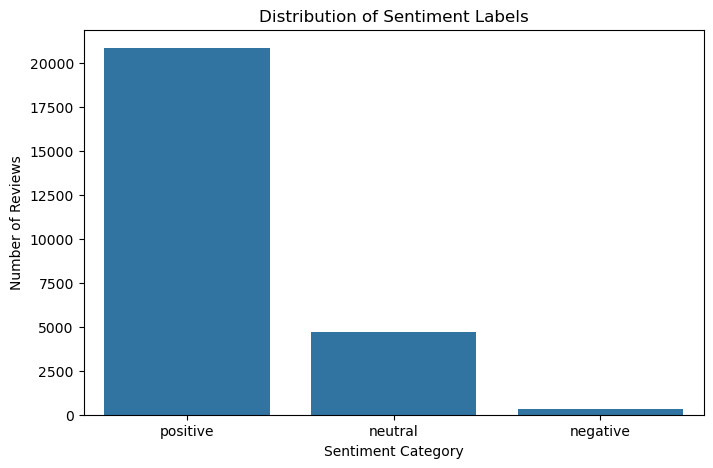

In [43]:
 # Visualize Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.show()


## Step 4. Data Splitting
The dataset is divided into training and testing sets to evaluate model performance

In [33]:
# Train-test split
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 20712
Test set size: 5179


## Step 5.  Baseline Model Training and Evaluation
We build a machine learning pipeline using TF-IDF and Naive Bayes, training it on the original imbalanced data to establish a realistic performance baseline.

Accuracy: 0.8795134195790694

--- Baseline Classification Report ---
              precision    recall  f1-score   support

    negative       1.00      0.05      0.09        65
     neutral       0.97      0.41      0.58       946
    positive       0.87      1.00      0.93      4168

    accuracy                           0.88      5179
   macro avg       0.95      0.49      0.53      5179
weighted avg       0.89      0.88      0.86      5179



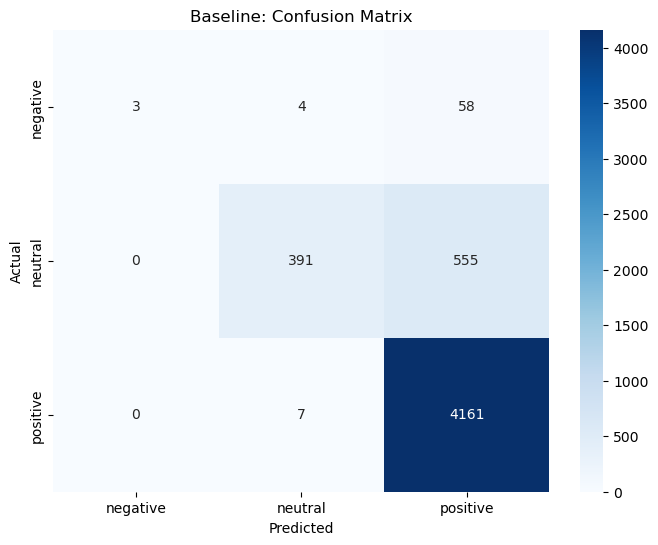

In [ ]:
# Define Pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('nb', MultinomialNB())
])

# Train on original data and Predict
nb_pipeline.fit(X_train, y_train)
y_pred = nb_pipeline.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\n--- Baseline Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred), 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nb_pipeline.classes_, 
    yticklabels=nb_pipeline.classes_
)
plt.title('Baseline: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Performance Evaluation
- **Overall Accuracy:** The model scores 88%, but this metric is heavily inflated because the dataset is overwhelmingly positive.
- **Negative Class (F1: 0.09):** The model is functionally blind to negatives, capturing a mere 5% of actual negative reviews.
- **Neutral Class (F1: 0.58):** Performance is mediocre, with the model missing 59% of the neutral reviews.
- **Positive Class (F1: 0.93):** Performance is near-perfect because the model safely over-predicts this massive majority class.

## Summary of Baseline Findings
1. Misleading Accuracy: The model achieved an accuracy of 88%, but this is an illusion of success.
2. Majority Bias: The model effortlessly finds 100% of the positive class simply by guessing it most of the time.
3. Imbalance Penalty: The natural class imbalance directly causes the model to fail at identifying minority classes.
4. Blind Spot: The model is functionally blind to the negative class, missing 95% of actual negative reviews.
5. Subpar Detection: The model struggled to identify neutral reviews, missing 59% of actual neutral cases.